In [2]:
import os 
import shutil
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from collections import Counter
import cv2
from collections import defaultdict

In [3]:
PATH_BRAIN_DATA = "../data/raw/brain-tumor-dataset-includes-the-mask-and-images/data/data"
PATH_BREAST_DATA= "../data/raw/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
OUTPUT_DIR_PREPROCESSING = "../data/processed"
SEED = 42
# We will randomly select 647 Brain Tumor images to match the number of Breast Tumor images
# (210 malignant and 437 benign) and create a balanced dataset.
NB_IMAGES_FOR_EACH_TUMOR_TYPE = 647
SIZE = (512, 512)

In [4]:
def separate_and_move_breast_images_masks(source_dir, destination_dir): 
    images = os.listdir(source_dir)
    images_dir = os.path.join(destination_dir, "images")
    masks_dir = os.path.join(destination_dir, "masks")
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    for img in images: 
        dest_img = img.replace('(', '').replace(')', '').replace(' ', '_').replace("benign", "breast_0") \
        .replace("malignant", "breast_1")
        if "_mask" in img: 
            shutil.copy(os.path.join(source_dir, img), os.path.join(masks_dir, dest_img))
        else: 
            shutil.copy(os.path.join(source_dir, img), os.path.join(images_dir, dest_img))


In [5]:

def randomly_select_and_move_brain_images_masks(source_dir, destination_dir): 
    source_images = os.path.join(source_dir, "images")
    source_masks = os.path.join(source_dir, "masks")

    destination_images = os.path.join(destination_dir, "images")
    destination_masks = os.path.join(destination_dir, "masks")

    os.makedirs(destination_images, exist_ok=True)
    os.makedirs(destination_masks, exist_ok=True)
    
    images = os.listdir(source_images)
    np.random.seed(SEED)

    images_selected = np.random.choice(
        images,
        size=NB_IMAGES_FOR_EACH_TUMOR_TYPE,
        replace=False
    )
    for img in images_selected: 
        name, ext = os.path.splitext(img)
        shutil.copy(os.path.join(source_images, img), os.path.join(destination_images, f'brain_{img}'))
        shutil.copy(os.path.join(source_masks, img), os.path.join(destination_masks, f'brain_{name}_mask{ext}'))


In [6]:
# Breast benign
separate_and_move_breast_images_masks(os.path.join(PATH_BREAST_DATA, "benign"), OUTPUT_DIR_PREPROCESSING)

# Breast malignant
separate_and_move_breast_images_masks(os.path.join(PATH_BREAST_DATA, "malignant"), OUTPUT_DIR_PREPROCESSING)

# Brain
randomly_select_and_move_brain_images_masks(os.path.join(PATH_BRAIN_DATA), OUTPUT_DIR_PREPROCESSING)

In [7]:
def get_images_masks(path):
    images = os.listdir(path+"/images")
    masks = os.listdir(path+"/masks")
    return images, masks

In [8]:
def info(images, masks): 
    nb_all_images = len(images)
    nb_all_masks = len(masks)
    nb_brain_images = len([img  for img in images if "brain" in img])
    nb_brain_masks = len([img for img in masks if "brain" in img])
    nb_breast_images = len([img for img in images if "breast" in img])
    nb_breast_masks = len([img for img in masks if "breast" in img ])
    print("Number of all images is:",nb_all_images )
    print("Number of all masks is:", nb_all_masks)
    print("Number of all brain images is:", nb_brain_images)
    print("Number of all brain masks is:", nb_brain_masks)
    print("Number of all breast images is:", nb_breast_images)
    print("Number of all breast masks is:", nb_breast_masks)

    return nb_all_images, nb_all_images, nb_brain_images, nb_brain_masks, nb_breast_images, nb_breast_masks
    

In [9]:
images, masks = get_images_masks(OUTPUT_DIR_PREPROCESSING)
nb_all_images, nb_all_images, nb_brain_images, nb_brain_masks, nb_breast_images, nb_breast_masks = info(images, masks)

Number of all images is: 1294
Number of all masks is: 1312
Number of all brain images is: 647
Number of all brain masks is: 647
Number of all breast images is: 647
Number of all breast masks is: 665


In [10]:
def display_barh(labels, values) : 
    fig, ax = plt.subplots(figsize=(8, 4))

    bars = ax.barh(labels, values)

    ax.invert_yaxis()

    # Ajouter les valeurs
    for bar in bars:
        value = bar.get_width()

        ax.text(
            value + 2,
            bar.get_y() + bar.get_height() / 2,
            str(value),
            va="center"
        )

    ax.set_xlabel("Number of Images")
    ax.set_title("Class Distribution")

    plt.tight_layout()
    plt.show()

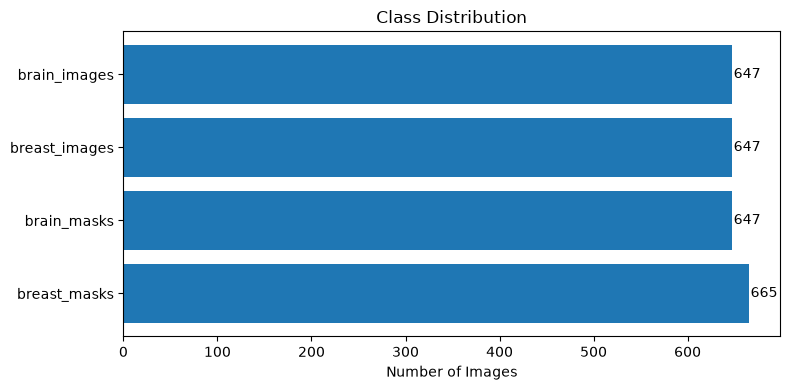

In [ ]:
labels = ['brain_images', 'breast_images', "brain_masks", "breast_masks"]
values = [nb_brain_images, nb_breast_images, nb_brain_masks, nb_breast_masks]
display_barh(labels, values)

---

The image dataset is well balanced, with 647 images for each tumor type, resulting in 1,294 images in total. However, the masks are not balanced because some Breast Tumor images have more than one corresponding mask.

---

In [12]:
def valide_masks(images, masks) : 
    for image in images: 
        if f'{image.split(".")[0]}_mask.png' not in masks: 
            print("This image '", image, "' not the mask.")
            break
    else :
        print("All images are the mask.")
    

In [13]:
valide_masks(images, masks)

All images are the mask.


In [14]:
def frequency_size(paths_images) :
    sizes = []
    for path in paths_images: 
        with Image.open(path) as img: 
            sizes.append(img.size)

    size_counter = Counter(sizes)
    most_common_size = size_counter.most_common(3)
    print(most_common_size)


In [15]:
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"images", img) for img in images])
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"masks", img) for img in masks])

[((512, 512), 643), ((557, 465), 6), ((564, 469), 4)]
[((512, 512), 643), ((557, 465), 6), ((544, 469), 4)]


In [16]:
def resize(path):
    masks_path = os.listdir(path)

    for mask_path in masks_path:
        p = os.path.join(path, mask_path)

        with Image.open(p) as mask:
            mask = mask.convert("L")
            mask = mask.resize(
                SIZE,
                Image.Resampling.NEAREST
            )

            mask.save(p)

In [17]:
resize(os.path.join(OUTPUT_DIR_PREPROCESSING, "images"))
resize(os.path.join(OUTPUT_DIR_PREPROCESSING, "masks"))
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"images", img) for img in images])
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"masks", img) for img in masks])

[((512, 512), 1294)]
[((512, 512), 1312)]


In [18]:
def display_images(images_paths):

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    axes = axes.flatten()

    for ax, img_path in zip(axes, images_paths):

        img = Image.open(img_path)

        ax.imshow(img, cmap="gray")
        ax.set_title(img_path.split("/")[-1])
        ax.axis("off")

    # Cacher les axes inutilisés
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print("")

In [19]:
path_images = sorted([OUTPUT_DIR_PREPROCESSING+"/images/"+img for img in images])
path_masks = sorted([OUTPUT_DIR_PREPROCESSING+"/masks/"+img for img in masks])

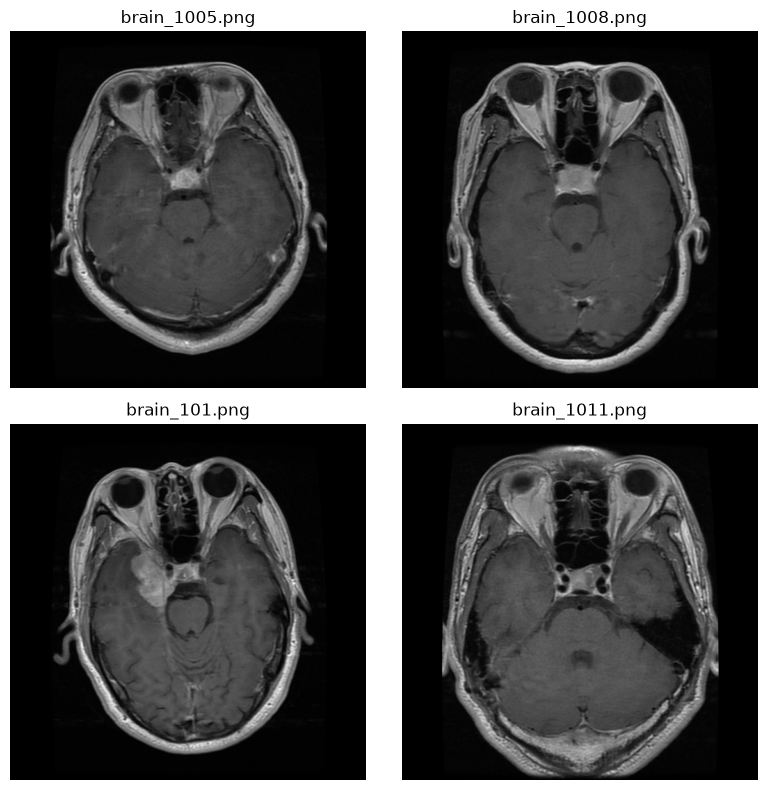

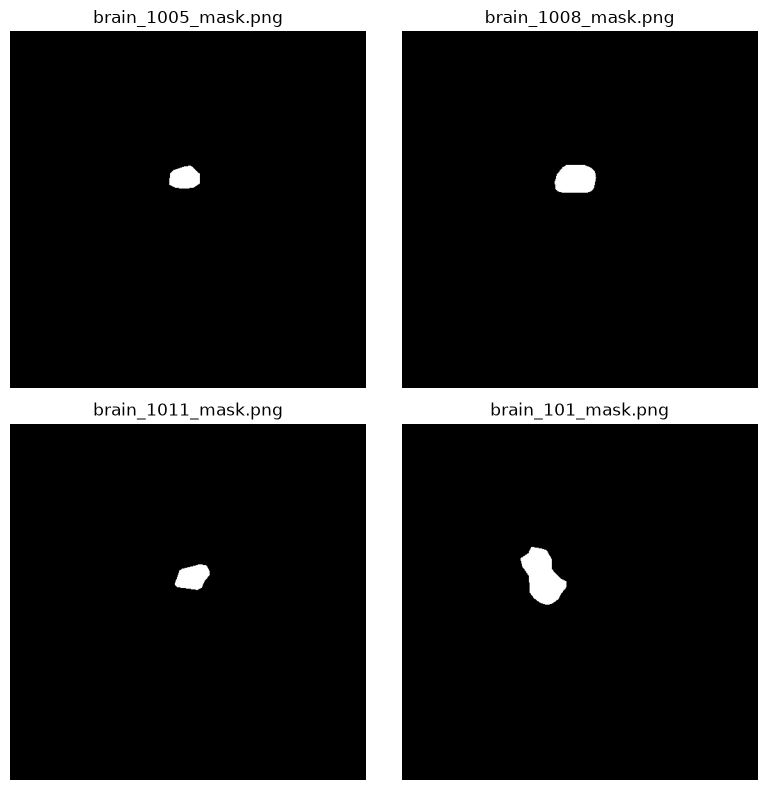

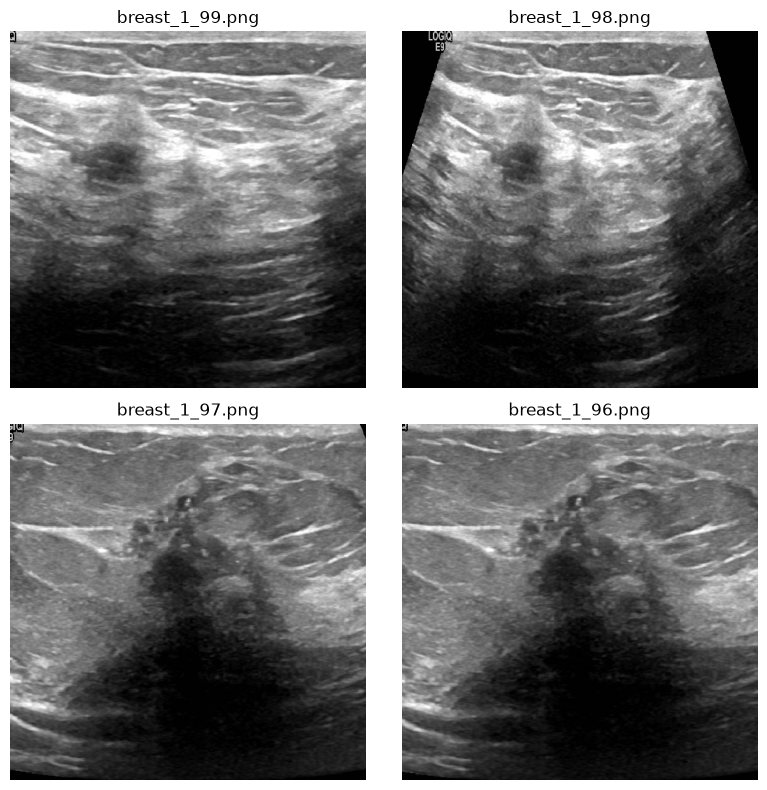

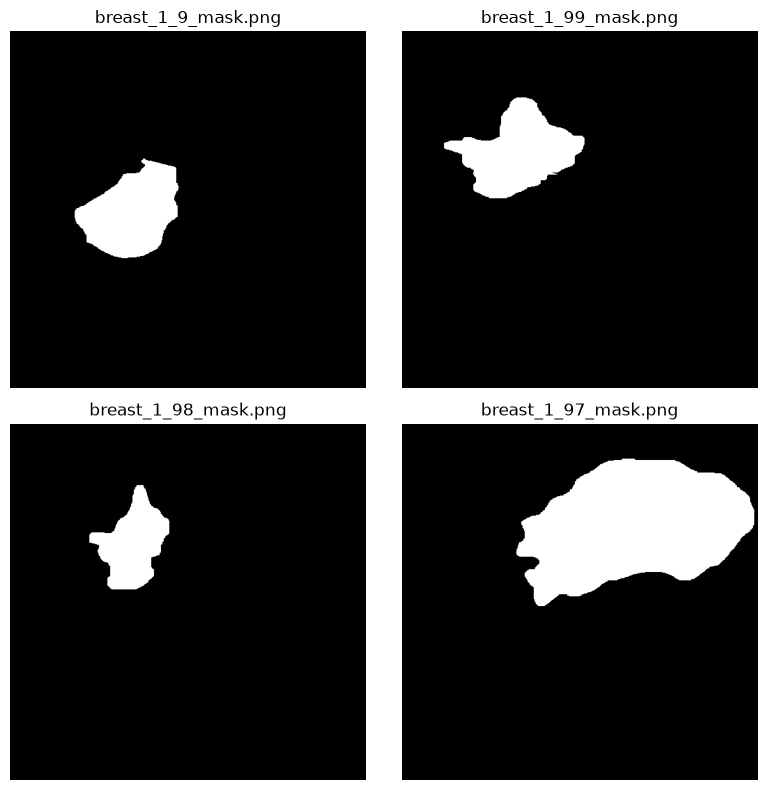

In [20]:
display_images(path_images)
display_images(path_masks)
display_images(reversed(path_images))
display_images(reversed(path_masks))

In [21]:
img = Image.open(OUTPUT_DIR_PREPROCESSING+"/masks/"+masks[10])
img = np.array(img)
np.unique(img)

array([  0, 255], dtype=uint8)

In [31]:
def nb_masks_for_image(masks):
    nb_masks = {}
    path_masks= {}
    for mask in masks : 
        img = mask.split("_mask")[0]
        nb_masks[img] =  nb_masks[img] + 1 if img in nb_masks.keys() else  1 
    for key, val in nb_masks.items() : 
        if val > 1 :
            path_masks[f'{key}_mask.png'] = val 
    return path_masks     


In [32]:
path_masks = nb_masks_for_image(masks)
print(path_masks)

{'breast_0_25_mask.png': 2, 'breast_0_315_mask.png': 2, 'breast_0_173_mask.png': 2, 'breast_0_54_mask.png': 2, 'breast_0_58_mask.png': 2, 'breast_0_424_mask.png': 2, 'breast_0_93_mask.png': 2, 'breast_0_181_mask.png': 2, 'breast_0_92_mask.png': 2, 'breast_1_53_mask.png': 2, 'breast_0_83_mask.png': 2, 'breast_0_346_mask.png': 2, 'breast_0_98_mask.png': 2, 'breast_0_195_mask.png': 3, 'breast_0_100_mask.png': 2, 'breast_0_4_mask.png': 2, 'breast_0_163_mask.png': 2}


In [35]:
def fusion_masks(masks_info):
    for mask_name, count in masks_info.items():
        mask_path = os.path.join(
            OUTPUT_DIR_PREPROCESSING,
            "masks",
            mask_name
        )

        # Load the first mask
        with Image.open(mask_path).convert("L") as mask:
            merged_mask = np.array(mask, dtype=np.uint8)

        name, ext = os.path.splitext(mask_name)

        # Merge the remaining masks
        for i in range(1, count):
            mask_path = os.path.join(
                OUTPUT_DIR_PREPROCESSING,
                "masks",
                f"{name}_{i}{ext}"
            )

            with Image.open(mask_path).convert("L") as mask:
                current_mask = np.array(mask, dtype=np.uint8)

            merged_mask = np.maximum(merged_mask, current_mask)

        # Convert to binary mask
        merged_mask = (merged_mask > 0).astype(np.uint8) * 255

        # Save the merged mask
        Image.fromarray(merged_mask).save(
            os.path.join(OUTPUT_DIR_PREPROCESSING, "masks", mask_name)
        )

        # Remove additional masks
        for i in range(1, count):
            mask_path = os.path.join(
                OUTPUT_DIR_PREPROCESSING,
                "masks",
                f"{name}_{i}{ext}"
            )

            if os.path.exists(mask_path):
                os.remove(mask_path)

In [36]:
fusion_masks(path_masks)

Number of all images is: 1294
Number of all masks is: 1294
Number of all brain images is: 647
Number of all brain masks is: 647
Number of all breast images is: 647
Number of all breast masks is: 647
[((512, 512), 1294)]
[((512, 512), 1294)]
The more masks : {}


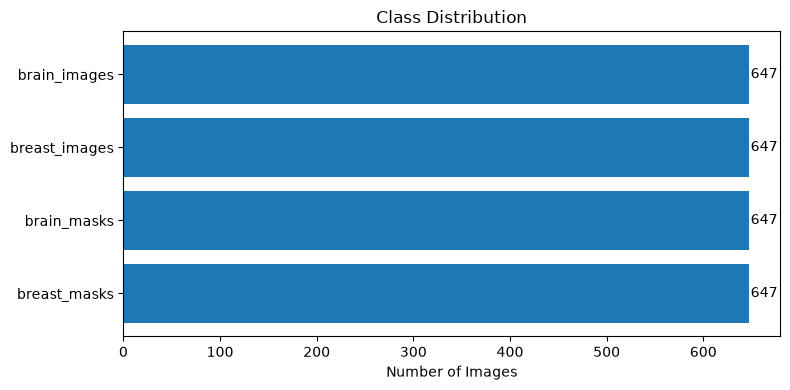

In [ ]:
images, masks = get_images_masks(OUTPUT_DIR_PREPROCESSING)
path_masks = nb_masks_for_image(masks)
nb_all_images, nb_all_images, nb_brain_images, nb_brain_masks, nb_breast_images, nb_breast_masks = info(images, masks)
labels = ['brain_images', 'breast_images', "brain_masks", "breast_masks"]
values = [nb_brain_images, nb_breast_images, nb_brain_masks, nb_breast_masks]
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"images", img) for img in images])
frequency_size([os.path.join(OUTPUT_DIR_PREPROCESSING,"masks", img) for img in masks])
print("The more masks :",path_masks)
display_barh(labels, values)

---

The preprocessing successfully produced a balanced dataset with 1,294 images and 1,294 corresponding masks. Both Brain Tumor and Breast Tumor datasets contain 647 images and 647 masks. All images and masks have been resized to 512×512, and each image now has exactly one corresponding mask.

---